In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import pickle
from pathlib import Path

import numpy as np
import numpy.random as npr
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from tqdm.notebook import tqdm

from imports import *
from config import dir_config
from src.utils import pmf_utils

In [ ]:
processed_dir = Path(dir_config.data.processed)
glm_hmm_dir = processed_dir / "glm_hmm"

# Change this to whichever model was selected as best in 5.24
SELECTED_MODEL = "no_standardization_curr_stim__global_pooled_cv"

GROUPS        = ["asmHC", "Tremor_OFF", "Brady_OFF", "Tremor_ON", "Brady_ON"]
GROUP_LABELS  = {"asmHC": "HC", "Tremor_OFF": "Tremor OFF", "Brady_OFF": "Brady OFF",
                 "Tremor_ON": "Tremor ON", "Brady_ON": "Brady ON"}
STATE_COLORS  = ["#ff7f00", "#4daf4a", "#377eb8", "#e41a1c", "#984ea3"]

STATE_NAMES = {
    "asmHC":      {1: "Unbiased", 2: "Lapse",      3: "Biased"},
    "Tremor_OFF": {1: "Unbiased", 2: "Lapse"},
    "Brady_OFF":  {1: "Mind biased"},
    "Tremor_ON":  {1: "Biased",   2: "Lapse",       3: "Unbiased"},
    "Brady_ON":   {1: "Unbiased", 2: "Lapse"},
}

# Set False to skip color-wise psychometric column (faster, no behavior_df needed)
PLOT_BEHAVIOR = True

behavior_df = (
    pd.read_csv(processed_dir / "processed_all_data_accu_60_all.csv")
    if PLOT_BEHAVIOR else None
)

In [4]:
def align_states(session_weights, ref_weights):
    """Hungarian-algorithm permutation mapping session states → reference states.

    Both arrays are (K, M).  Returns an integer array `perm` of length K such
    that session_weights[i] is matched to reference state perm[i].
    """
    K = session_weights.shape[0]
    cost = np.array([[np.sum((session_weights[i] - ref_weights[j]) ** 2)
                      for j in range(K)] for i in range(K)])
    _, col_ind = linear_sum_assignment(cost)
    # col_ind[i] = reference state that session state i is matched to.
    # We need the inverse: new_order[ref_state] = session_state.
    inv = np.empty_like(col_ind)
    inv[col_ind] = np.arange(K)
    return inv  # apply as: aligned[k] = session[inv[k]]


def load_and_align_group(model_dir, group_name, behavior_df=None):
    """Load a finetuned bundle, align every session model to the group pooled model.

    Returns a dict with per-session aligned weights, posteriors, and occupancy,
    plus the reference (pooled) weights and the config.  If behavior_df is
    supplied, also computes per-session predicted_dfs (stimulus / choices /
    color / expected_choice_prob) used for the color-wise psychometric.
    """
    pkl_path = model_dir / f"{group_name}_final.pkl"
    if not pkl_path.exists():
        print(f"  Missing: {pkl_path}")
        return None

    bundle = pickle.load(open(pkl_path, "rb"))
    config     = bundle["config"]
    ref_model  = bundle["model"]["pooled"]
    ref_w      = -ref_model.observations.params[:, 0, :]  # (K, M)

    session_weights    = {}
    session_posteriors = {}
    session_occupancy  = {}
    session_predicted_dfs = {} if behavior_df is not None else None

    for session_id, sess_model in bundle["model"]["models"].items():
        sess_w = -sess_model.observations.params[:, 0, :]  # (K, M)
        perm   = align_states(sess_w, ref_w)               # length-K permutation

        session_weights[session_id] = sess_w[perm]         # (K, M)

        # Forward-backward over the full session sequence
        glm_df     = bundle["data"][session_id]
        all_data   = glm_df["choices"].values.astype(int).reshape(-1, 1)
        all_inputs = glm_df[config["model_features"]].values.astype(np.float64)
        all_masks  = glm_df["mask"].values.astype(bool).reshape(-1, 1)

        post = sess_model.expected_states(
            data=all_data, input=all_inputs, mask=all_masks
        )[0]  # (T, K)
        aligned_post = post[:, perm]                       # (T, K)
        session_posteriors[session_id] = aligned_post

        valid = all_masks[:, 0]
        session_occupancy[session_id] = aligned_post[valid].mean(axis=0)  # (K,)

        # ── optional: build predicted_df with color for psychometric plot ────
        if behavior_df is not None:
            trial_data = behavior_df[behavior_df["session_id"] == session_id].reset_index(drop=True)
            valid_idx  = np.where(trial_data["outcome"] >= 0)[0]
            first_trial = valid_idx[config["n_trials_back"] - 1] + 1
            sess_df    = trial_data.iloc[first_trial:].reset_index(drop=True)

            if len(glm_df) != len(sess_df):
                continue  # skip if lengths don't match

            # expected_choice_prob is permutation-invariant (state-averaged)
            w      = -sess_model.observations.params       # (K, 1, M)
            wsums  = np.einsum("tm,km->tk", all_inputs, w[:, 0, :])
            sig    = 1 / (1 + np.exp(-wsums))
            exp_p  = (sig * post).sum(axis=1)              # (T,)

            K_s = post.shape[1]
            pdf = pd.DataFrame(
                {f"posterior_probs_state_{i+1}": aligned_post[valid, i] for i in range(K_s)}
            )
            pdf["expected_choice_prob"] = exp_p[valid]
            pdf["choices"]  = all_data[valid, 0]
            pdf["stimulus"] = glm_df["stimulus"].values[valid]
            pdf["color"]    = sess_df["color"].values[valid]
            session_predicted_dfs[session_id] = pdf

    return {
        "config":                 config,
        "best_k":                 bundle["best_k"],
        "ref_weights":            ref_w,
        "session_weights":        session_weights,
        "session_posteriors":     session_posteriors,
        "session_occupancy":      session_occupancy,
        "session_predicted_dfs":  session_predicted_dfs,
    }

In [5]:
model_dir  = glm_hmm_dir / SELECTED_MODEL
group_data = {}

for group in GROUPS:
    data = load_and_align_group(model_dir, group, behavior_df=behavior_df)
    if data is not None:
        group_data[group] = data
        print(f"{group:12s}  K={data['best_k']}  n_sessions={len(data['session_weights'])}")

asmHC         K=3  n_sessions=18
Tremor_OFF    K=2  n_sessions=11
Brady_OFF     K=1  n_sessions=10
Tremor_ON     K=3  n_sessions=11
Brady_ON      K=2  n_sessions=10


In [6]:
def get_state_colors(K):
    if K <= len(STATE_COLORS):
        return STATE_COLORS[:K]
    return [plt.cm.tab10.colors[k % 10] for k in range(K)]


def get_state_label(group, k):
    return STATE_NAMES.get(group, {}).get(k + 1, f"State {k+1}")


# ── color-wise psychometric helpers (1.20 style) ──────────────────────────────

def compute_group_psychometrics(predicted_dfs):
    """Per-session and group-averaged psychometrics for Equal/Unequal color.

    Returns dict keyed by color value (0=Equal, 1=Unequal), each entry has:
        label, color, x_bins, x_hat,
        actual_per_session, model_per_session,
        mean_actual, sem_actual, mean_model, sem_model,
        fit_actual_y, fit_model_y
    """
    conditions = [(0, "Equal", "gray"), (1, "Unequal", "black")]
    result = {}

    for color_val, label, color in conditions:
        actual_sessions, model_sessions = [], []
        x_bins_ref = x_hat_ref = None

        for pdf in predicted_dfs.values():
            sub = pdf[pdf["color"] == color_val]
            if len(sub) < 5:
                continue
            stim = sub["stimulus"].to_numpy() * 100
            ch   = sub["choices"].values.astype(int)
            ep   = np.clip(sub["expected_choice_prob"].values, 1e-6, 1 - 1e-6)

            try:
                x_d, y_d, _, x_hat, _ = pmf_utils.get_psychometric_data(
                    {"signed_coherence": stim, "choice": ch}
                )
                actual_sessions.append(y_d)
                if x_bins_ref is None:
                    x_bins_ref, x_hat_ref = x_d, x_hat

                sim = npr.binomial(1, ep)
                _, y_m, _, _, _ = pmf_utils.get_psychometric_data(
                    {"signed_coherence": stim, "choice": sim}
                )
                model_sessions.append(y_m)
            except Exception:
                continue

        if not actual_sessions:
            continue

        y_a = np.array(actual_sessions)   # (S, n_bins)
        y_m = np.array(model_sessions)
        S   = len(actual_sessions)

        mean_a, sem_a = y_a.mean(0), y_a.std(0) / np.sqrt(S)
        mean_m, sem_m = y_m.mean(0), y_m.std(0) / np.sqrt(S)

        def safe_fit(x, y):
            try:
                fit = pmf_utils.fit_psychometric_function(
                    x, y, trial_counts=None, model_type="logit_4"
                )
                return fit.predict(x_hat_ref)
            except Exception:
                return None

        result[color_val] = {
            "label": label, "color": color,
            "x_bins": x_bins_ref, "x_hat": x_hat_ref,
            "actual_per_session": actual_sessions,
            "model_per_session":  model_sessions,
            "mean_actual": mean_a, "sem_actual": sem_a,
            "mean_model":  mean_m, "sem_model":  sem_m,
            "fit_actual_y": safe_fit(x_bins_ref, mean_a),
            "fit_model_y":  safe_fit(x_bins_ref, mean_m),
        }

    return result


def plot_color_psych(ax, group_psych, mode, title=""):
    """1.20-style: faded per-session lines + group mean \u00b1 SEM + fitted curve.

    mode: 'actual' (real choices) or 'model' (GLM-HMM expected_choice_prob).
    """
    err_kw = {"elinewidth": 2, "capsize": 8, "capthick": 2}

    for color_val in sorted(group_psych):
        cond     = group_psych[color_val]
        c        = cond["color"]
        x_bins   = cond["x_bins"]
        x_hat    = cond["x_hat"]
        sessions = cond[f"{mode}_per_session"]
        mean_y   = cond[f"mean_{mode}"]
        sem_y    = cond[f"sem_{mode}"]
        fit_y    = cond[f"fit_{mode}_y"]

        for y_s in sessions:
            ax.plot(x_bins, y_s, "o-", color=c, alpha=0.08, lw=0.8, ms=3)

        ax.errorbar(x_bins, mean_y, yerr=sem_y, color=c,
                    marker="o", ms=10, mec="k", ls="",
                    label=cond["label"], **err_kw)

        if fit_y is not None:
            ax.plot(x_hat, fit_y, color=c, ls="-", lw=3)

    ax.axhline(0.5, color="k", ls=":", lw=0.8)
    ax.set(xlabel="Coherence (%)", ylabel="P(right)",
           xlim=(-105, 105), ylim=(-0.05, 1.05),
           xticks=[-100, -35, -13, 0, 13, 35, 100],
           title=title)
    ax.tick_params(labelsize=10)
    ax.legend(fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ── main per-group plotting function ─────────────────────────────────────────

def plot_group(axes, group, gdata):
    """Plot one group row.

    Without behavior_df -> axes is 3-tuple (state_psych, weights, occ)
    With    behavior_df -> axes is 5-tuple (behavior, glm_psych, state_psych, weights, occ)
    """
    predicted_dfs = gdata.get("session_predicted_dfs")
    has_behavior  = predicted_dfs is not None and len(predicted_dfs) > 0
    group_label   = GROUP_LABELS.get(group, group)

    if has_behavior:
        ax_beh, ax_mdl, ax_psych, ax_weights, ax_occ = axes
        group_psych = compute_group_psychometrics(predicted_dfs)
        plot_color_psych(ax_beh, group_psych, "actual",
                         title=f"{group_label} \u2014 Behavior")
        plot_color_psych(ax_mdl, group_psych, "model",
                         title=f"{group_label} \u2014 GLM-HMM")
    else:
        ax_psych, ax_weights, ax_occ = axes

    K      = gdata["best_k"]
    config = gdata["config"]
    feats  = config["model_features"]
    colors = get_state_colors(K)

    all_weights   = np.stack(list(gdata["session_weights"].values()))   # (S, K, M)
    all_occupancy = np.stack(list(gdata["session_occupancy"].values()))  # (S, K)
    S = all_weights.shape[0]

    mean_w   = all_weights.mean(0)
    sem_w    = all_weights.std(0) / np.sqrt(S)
    mean_occ = all_occupancy.mean(0)
    sem_occ  = all_occupancy.std(0) / np.sqrt(S)

    # per-state sigmoid psychometric from mean weights
    stim_idx   = feats.index("stimulus") if "stimulus" in feats else 0
    bias_idx   = feats.index("bias") if "bias" in feats else None
    stim_range = np.linspace(-1, 1, 200)

    for k in range(K):
        label = get_state_label(group, k)
        logit = mean_w[k, stim_idx] * stim_range
        if bias_idx is not None:
            logit = logit + mean_w[k, bias_idx]
        ax_psych.plot(stim_range * 100, 1 / (1 + np.exp(-logit)),
                      color=colors[k], lw=2, label=label)
    ax_psych.axhline(0.5, color="k", ls=":", lw=0.8)
    ax_psych.set(xlabel="Coherence (%)", ylabel="P(right)", ylim=(0, 1),
                 title=group_label)
    ax_psych.legend(fontsize=8)

    # GLM weights
    x = np.arange(len(feats))
    for k in range(K):
        ax_weights.errorbar(x, mean_w[k], yerr=sem_w[k],
                            color=colors[k], marker="o", lw=1.5, capsize=3,
                            label=get_state_label(group, k))
    ax_weights.axhline(0, color="k", ls="--", lw=0.8)
    ax_weights.set_xticks(x)
    ax_weights.set_xticklabels(feats, rotation=20, ha="right", fontsize=9)
    ax_weights.set(ylabel="GLM weight", title="Weights (mean \u00b1 SEM)")
    ax_weights.legend(fontsize=8)

    # state occupancy
    xk = np.arange(K)
    ax_occ.bar(xk, mean_occ, color=colors, alpha=0.8, yerr=sem_occ,
               capsize=4, error_kw={"elinewidth": 1.5})
    for k in range(K):
        ax_occ.scatter(np.full(S, k) + np.random.uniform(-0.15, 0.15, S),
                       all_occupancy[:, k], color=colors[k],
                       s=12, alpha=0.6, zorder=3)
    ax_occ.set_xticks(xk)
    ax_occ.set_xticklabels([get_state_label(group, k) for k in range(K)])
    ax_occ.set(ylabel="Fraction of trials", ylim=(0, 1), title="State occupancy")


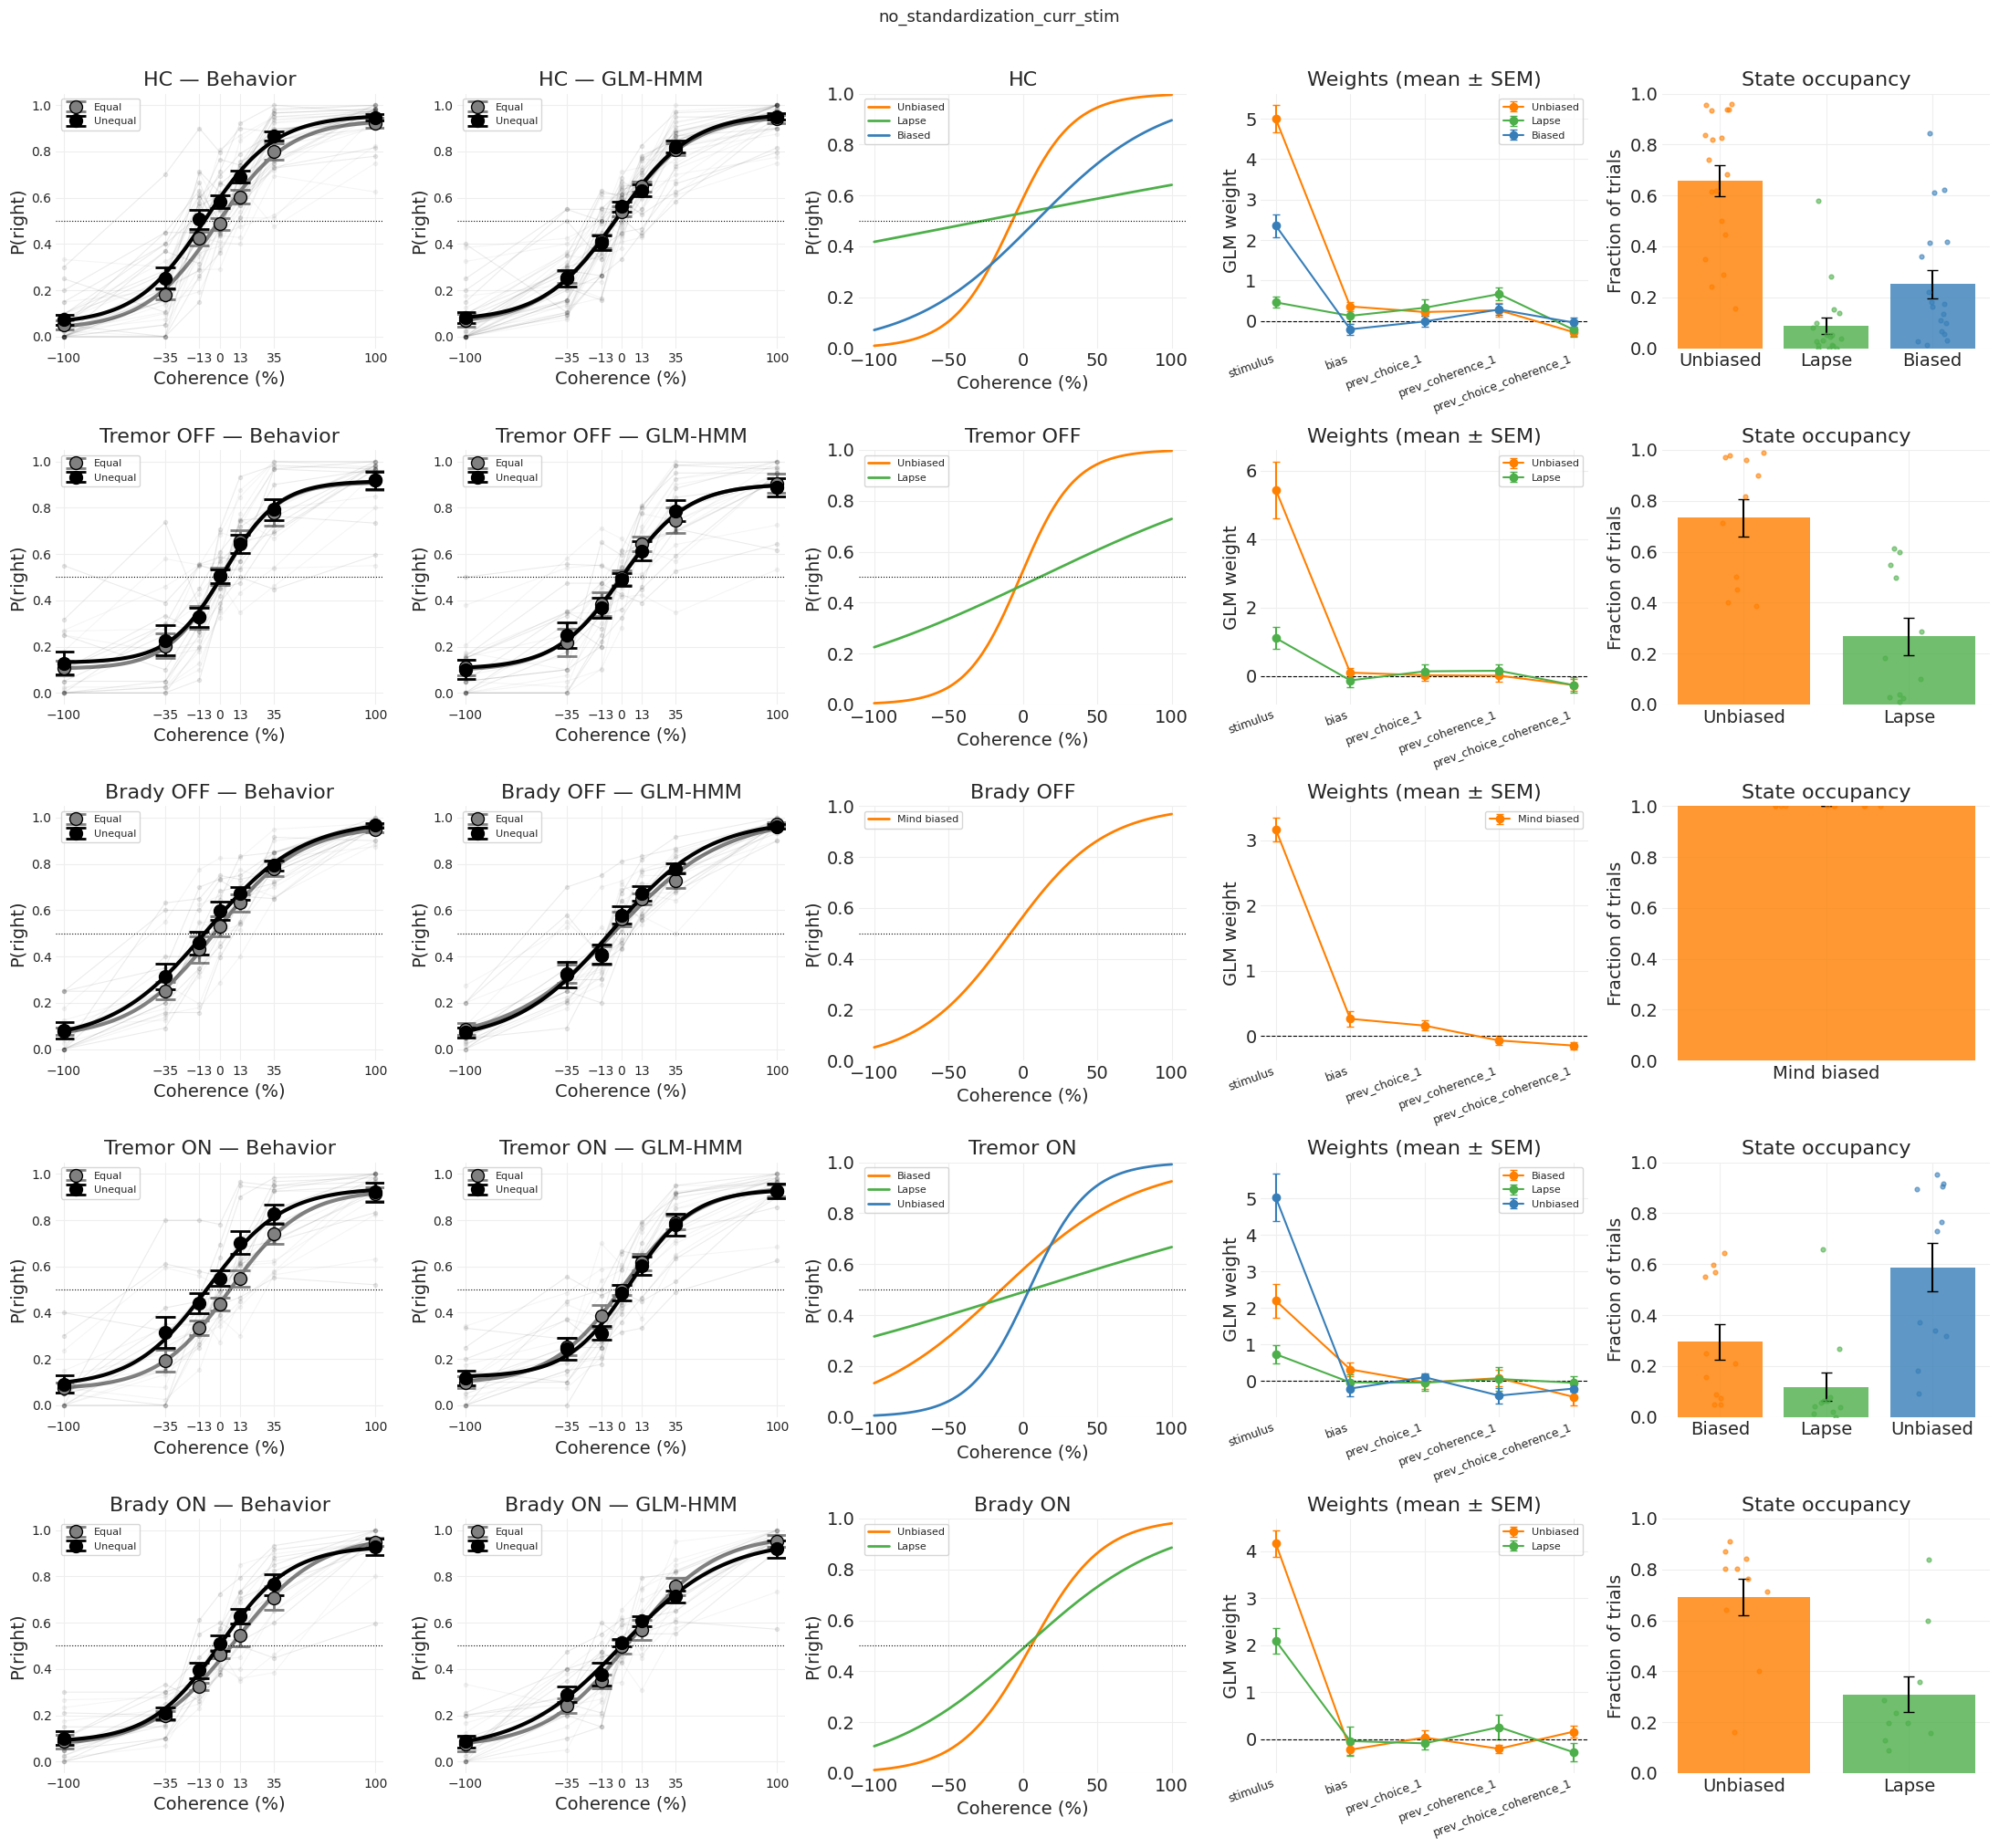

In [7]:
n_groups     = len(group_data)
has_behavior = any(
    g.get("session_predicted_dfs") is not None and len(g["session_predicted_dfs"]) > 0
    for g in group_data.values()
)
n_cols = 5 if has_behavior else 3
fig_w  = 22 if has_behavior else 14

fig, axes = plt.subplots(n_groups, n_cols, figsize=(fig_w, 4 * n_groups))
if n_groups == 1:
    axes = axes[np.newaxis, :]

for row, group in enumerate(GROUPS):
    if group not in group_data:
        continue
    plot_group(axes[row, :n_cols], group, group_data[group])

plt.suptitle(SELECTED_MODEL.replace("__global_pooled_cv", ""), fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


# Mapping states between groups

HC => state 1: unbiased, state 2: lapse, state 3: biased


Tremor OFF => state 1: unbiased, state 2: lapse


Brady OFF => state 1: mind biased


Tremor ON => state 1: biased. state 2: lapse, state 3: unbiased


Brady ON => state 1: unbiased, state 2: lapse